In [1]:
import torch
import torch.nn as nn
from torch.optim import SGD
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
x = [[1,2],[3,4],[5,6],[7,8]]
y = [[3],[7],[11],[15]]

In [3]:
X = torch.tensor(x).float()
Y = torch.tensor(y).float()

In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
X = X.to(device)
Y = Y.to(device)

In [6]:
class MyNeuralNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2, 8)
        self.activation = nn.ReLU()
        self.layer2 = nn.Linear(8,1)

    def forward(self,x):
        x = self.layer1(x)
        x = self.activation(x)
        x = self.layer2(x)
        return x

In [7]:
model = MyNeuralNet()

In [8]:
loss_func = nn.MSELoss()

In [9]:
opt = SGD(model.parameters(), lr = 0.001)

In [ ]:
losses = []
for _ in range(50):
    opt.zero_grad() # zera gradiente antes de cada passo
    loss_value = loss_func(model(X), Y) # forward + cálculo da loss
    loss_value.backward() # backward calcula os gradientes

    opt.step() # atualiza os pesos
    losses.append(loss_value.detach().numpy())  # guarda o valor só pra plotar depois

Text(0, 0.5, 'loss value')

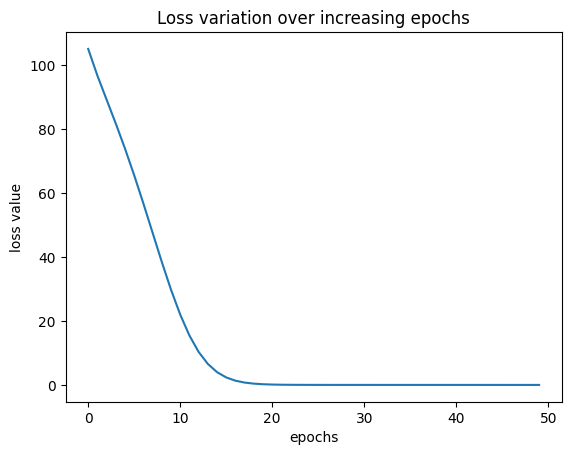

In [12]:
plt.plot(losses)
plt.title('Loss variation over increasing epochs')
plt.xlabel('epochs')
plt.ylabel('loss value')